# Import

In [19]:
import pandas as pd
import emoji
from wordcloud import WordCloud
import nltk
import matplotlib.pyplot as plt
from collections import Counter

import re
# nltk.download('stopwords')
from nltk.corpus import stopwords

In [2]:
df = pd.read_parquet('train.parquet')
df.head()

,text,label
0,hey I am looking for Xray baggage datasets can...,not_spam
1,"""Get rich quick! Make millions in just days wi...",spam
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam
4,Trying to see if anyone already has timestamps...,not_spam


In [11]:
df.shape

(8175, 2)

In [12]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [13]:
df['label'].value_counts()

label
spam        4125
not_spam    4050
Name: count, dtype: int64

# EDA

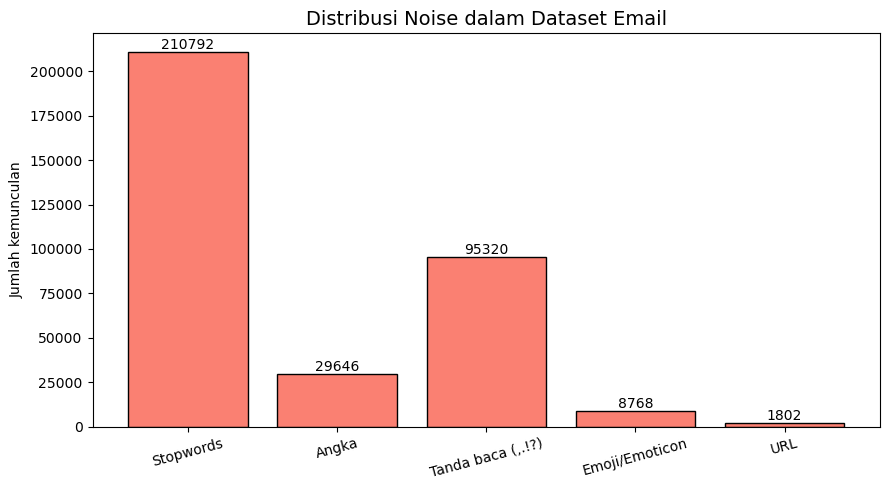

In [11]:
spam_text = ' '.join(df['text'].tolist())
stopword_en = set(stopwords.words('english'))

noise = {
    'Stopwords': sum(spam_text.lower().split().count(w) for w in stopword_en),
    'Angka': len(re.findall(r'\d', spam_text)),
    'Tanda baca (,.!?)': len(re.findall(r'[,\.!?;:\"\']', spam_text)),
    'Emoji/Emoticon': len(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', spam_text)),
    'URL': len(re.findall(r'http\S+|www\S+', spam_text)),
}

plt.figure(figsize=(9, 5))
bars = plt.bar(noise.keys(), noise.values(), color='salmon', edgecolor='black')
plt.bar_label(bars)
plt.title('Distribusi Noise dalam Dataset Email', fontsize=14)
plt.ylabel('Jumlah kemunculan')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [37]:
print(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', spam_text))

['👋', '👋', '👋', '😴', '😒', '🌶', '🌶', '🌶', '💪', '🏃', '🥦', '💪', '💪', '💪', '🙌', '🙌', '🙌', '🤩', '🤩', '🤩', '👋', '💥', '🤳', '🤳', '💻', '🔥', '🚫', '🔥', '🔥', '🤑', '💰', '💰', ':)', '👀', '📣', '📈', '🚀', '🤑', '👉', '💕', '💬', '🔧', '🛠', '👍', '📝', '👥', '🤩', '🌸', '🌸', '🌸', '🤩', '🤩', '🤩', '😝', '😝', '😝', '🤯', '🤯', '🤯', ';D', '😩', ':)', ':-|', ':-|', ':-|', '🎉', '🎉', '🎉', ';)', '🚨', '🚨', '🦐', '🦐', '🍔', '🍔', '🍟', '🍟', '💥', '💥', '🎁', '🤯', '🔥', '💥', '👨', '🎤', '👩', '🎤', '🔞', '🦄', '🤑', '🤑', '🤑', '🏃', '🏃', '🏃', '🥑', '🎉', '🥳', '💥', '🤑', '💪', '👟', '🌴', '🌞', '👀', '💬', '🤑', '💰', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '👉', '🏼', '🤯', '🤯', '🚫', '👉', '🤑', '🎉', '👍', '🙌', '🚨', '🚨', '🚨', '🚨', '🚨', '🚨', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🎉', '🎉', '🎉', '🎉', '🎉', '🎉', '🤑', '🤑', '🤑', '🤑', '🤑', '🚨', '🚨', '🏋', '🏋', '💪', '💪', '📚', '🤑', '💰', '🤑', '💰', '🤑', '📣', '📣', '📣', '😎', '🚨', '🚨', '🎉', '🎉', '🎉', '🤡', '🐱', '😜', '😂', '👌', '🔥', '🔥', '🔥', '🤑', '🤑', '🤑', '🎉', '🎉', '🎉', '🥧', '🥧', '🥧', '💰', '💰', '💰', '=p', '=p', '=p', '👉', '👉', '👉', '🤑', '

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_4312\1099320839.py:60: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


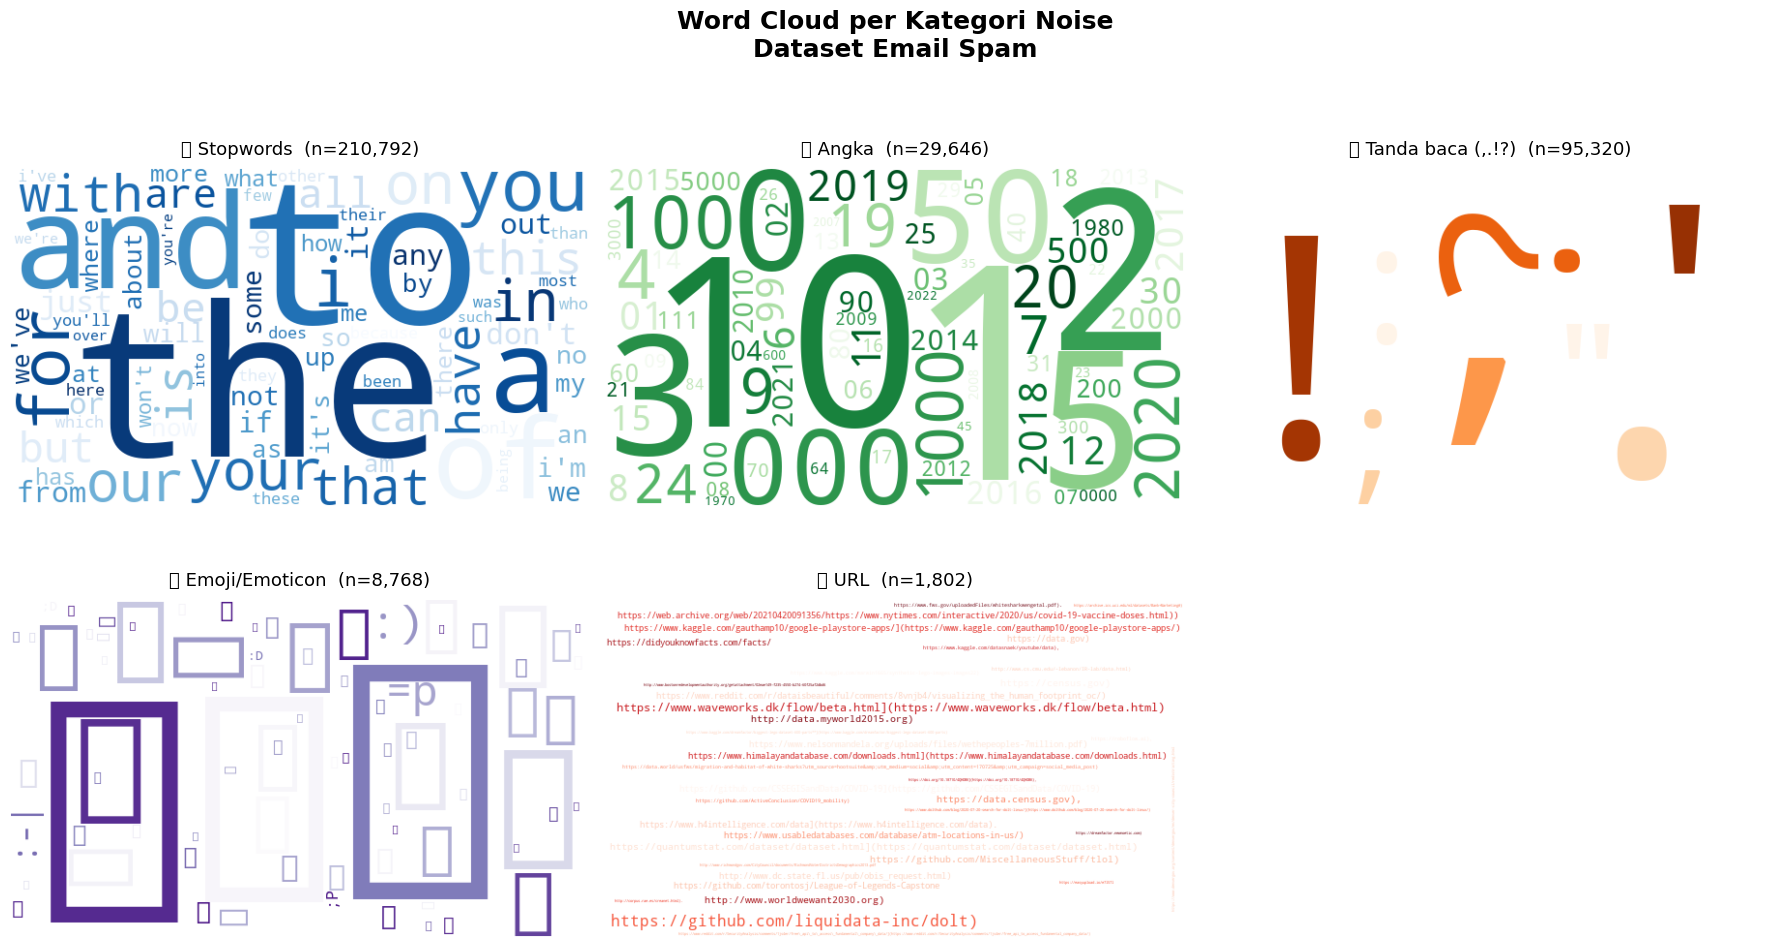

In [17]:
# ── Bangun freq dict untuk tiap key di noise ──────────────────────────────────
tokens = spam_text.lower().split()

noise_freq = {
    'Stopwords':            Counter(w for w in tokens if w in stopword_en),
    'Angka':                Counter(re.findall(r'\b\d+\b', spam_text)),
    'Tanda baca (,.!?)':    Counter(re.findall(r'[,\.!?;:\"\']', spam_text)),
    'Emoji/Emoticon':       Counter(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', spam_text)),
    'URL':                  Counter(re.findall(r'http\S+|www\S+', spam_text)),
}

# ── Colormap per kategori ─────────────────────────────────────────────────────
cmap_map = {
    'Stopwords':            'Blues',
    'Angka':                'Greens',
    'Tanda baca (,.!?)':    'Oranges',
    'Emoji/Emoticon':       'Purples',
    'URL':                  'Reds',
}

# ── make_wc helper ────────────────────────────────────────────────────────────
def make_wc(freq_dict, colormap, max_words=80):
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=colormap,
        max_words=max_words,
        collocations=False,
    )
    if freq_dict:
        wc.generate_from_frequencies(freq_dict)
    return wc

# ── Plot — otomatis ikut jumlah key di noise ──────────────────────────────────
n     = len(noise)
ncols = 3
nrows = -(-n // ncols)   # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))
fig.suptitle('Word Cloud per Kategori Noise\nDataset Email Spam',
             fontsize=18, fontweight='bold', y=1.01)

for ax, (label, freq) in zip(axes.flatten(), noise_freq.items()):
    cmap = cmap_map.get(label, 'cool')
    if freq:
        wc = make_wc(freq, cmap)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'🔹 {label}  (n={noise[label]:,})', fontsize=13, pad=10)
    else:
        ax.text(0.5, 0.5, 'Tidak ditemukan',
                ha='center', va='center', fontsize=13, color='gray',
                transform=ax.transAxes)
        ax.set_title(f'🔹 {label}', fontsize=13, pad=10)
    ax.axis('off')

# Sembunyikan ax kosong jika noise ganjil
for ax in axes.flatten()[n:]:
    ax.set_visible(False)

plt.tight_layout()
# plt.savefig('wordcloud_noise.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
print(df['text'].apply(len).mean())
print(df['text'].apply(len).max())
print(df['text'].apply(len).min())

369.11131498470945
41544
2


In [39]:
df['text_lenght'] = df['text'].apply(len)

In [41]:
df[df['text_lenght'] == 41544]

,text,label,text_lenght
6262,I've made a zip code-level data retriever in R...,not_spam,41544


In [53]:
df[df['text_lenght'] == 0]

,text,label,text_lenght,text_casefolded


# Casefolding and Normalization

In [56]:
df.drop(['text_casefolded'], axis=1, inplace=True)

In [63]:
# lowercase
df['text_normalized'] = df['text'].str.lower()

# Remove \n
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub('\\n',' ', x).strip())

# Remove url
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub(
                                                    r'https?://\S+'      # https://... atau http://...
                                                    r'|www\.\S+'         # www....
                                                    r'|\S+\.\S+\.\S+'    # subdomain.domain.tld (links.aaruush.org)
                                                    r'|\S+\.(com|org|net|id|io|co|info|edu|gov)\S*',  # domain.tld umum
                                                    '', x))

# Remove URL
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]','', x).strip())

In [65]:
df[['text_normalized','text']]

,text_normalized,text
0,hey i am looking for xray baggage datasets can...,hey I am looking for Xray baggage datasets can...
1,"""get rich quick! make millions in just days wi...","""Get rich quick! Make millions in just days wi..."
2,urgent message: you won't believe what we have...,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...
3,[google ai blog: contributing data to deepfake...,[Google AI Blog: Contributing Data to Deepfake...
4,trying to see if anyone already has timestamps...,Trying to see if anyone already has timestamps...
...,...,...
8170,"hi all, we create datasets by taking pictures...","Hi all,\n\nWe create datasets by taking pictur..."
8171,deals! deals! deals! hey peeps! you won't bel...,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...
8172,hi i am working on a project and need penalty...,Hi\n\nI am working on a project and need penal...
8173,do you want to blow up your social media follo...,Do you want to BLOW UP your social media follo...


# Remove stoprword

In [ ]:
df['text_remove_sw'] = df['text'].apply(lambda x: x.split())

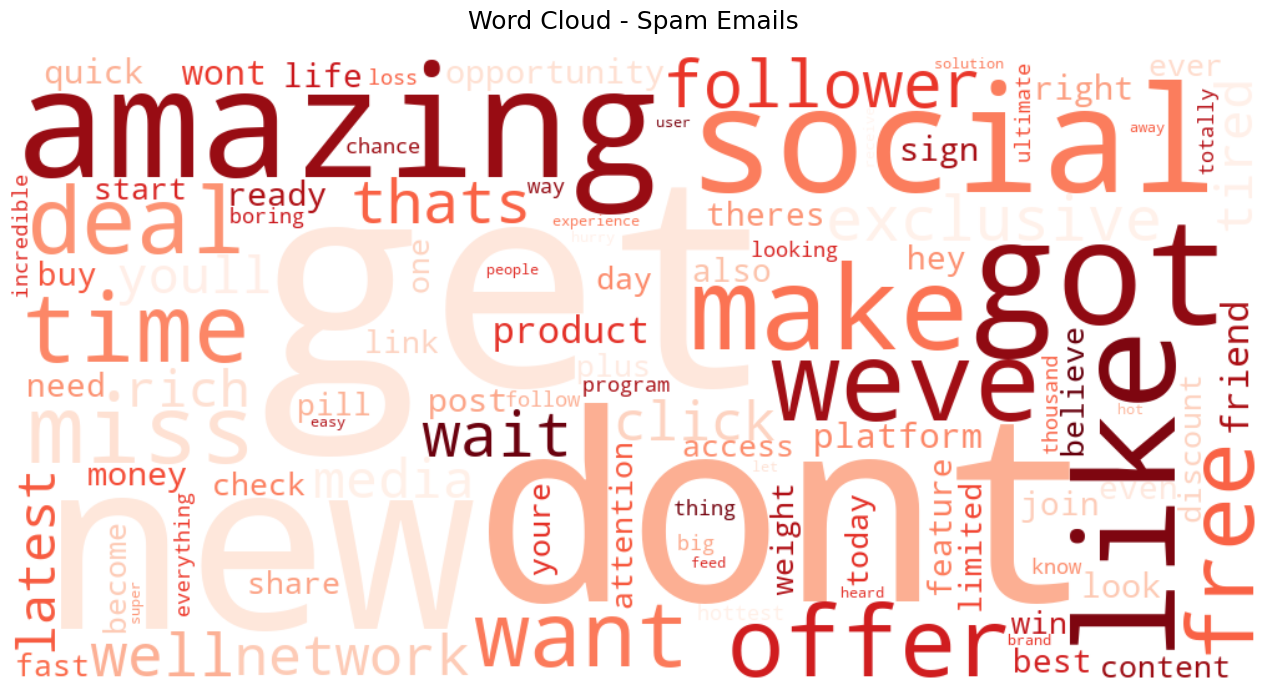

In [21]:
def clean_text(text):
    # 1. Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # 2. Hapus emoticon/emoji
    text = emoji.replace_emoji(text, replace='')
    
    # 3. Hapus karakter spesial (koma, titik, tanda seru, dll.)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 4. Lowercase
    text = text.lower()
    
    # 5. Hapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Gabungkan semua teks spam, lalu bersihkan
raw_text = ' '.join(df[df['label'] == 'spam']['text'].dropna().tolist())
clean = clean_text(raw_text)

# Stopwords: gabungkan NLTK + WordCloud built-in
# stop_words = set(STOPWORDS).union(set(stopwords.words('english')))

# Tambah stopword custom kalau ada kata yang masih muncul tapi ga informatif
# custom_stops = {'will', 'get', 'now', 'just', 'u', 'ur'}
# stop_words.update(custom_stops)

# Generate WordCloud
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stopword_en,
    colormap='Reds',
    max_words=100,
    collocations=False,      # hindari "free free" dihitung dua kali
    min_word_length=3        # skip kata < 3 huruf (ex: "im", "ok")
).generate(clean)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Spam Emails', fontsize=18, pad=20)
plt.tight_layout()
plt.show()


In [23]:
df

,text,label
0,hey I am looking for Xray baggage datasets can...,not_spam
1,"""Get rich quick! Make millions in just days wi...",spam
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam
4,Trying to see if anyone already has timestamps...,not_spam
...,...,...
8170,"Hi all,\n\nWe create datasets by taking pictur...",not_spam
8171,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...,spam
8172,Hi\n\nI am working on a project and need penal...,not_spam
8173,Do you want to BLOW UP your social media follo...,spam


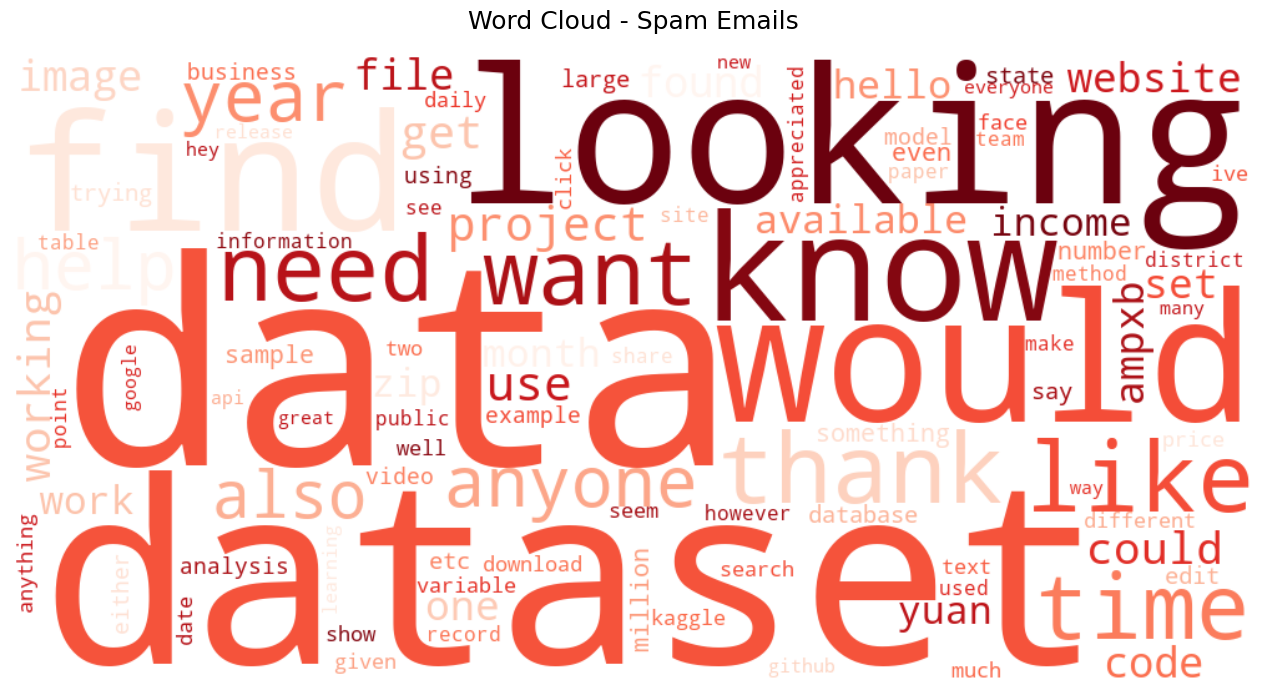

In [25]:
def clean_text(text):
    # 1. Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # 2. Hapus emoticon/emoji
    text = emoji.replace_emoji(text, replace='')
    
    # 3. Hapus karakter spesial (koma, titik, tanda seru, dll.)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 4. Lowercase
    text = text.lower()
    
    # 5. Hapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Gabungkan semua teks spam, lalu bersihkan
raw_text = ' '.join(df[df['label'] == 'not_spam']['text'][:100].dropna().tolist())
clean = clean_text(raw_text)

# Stopwords: gabungkan NLTK + WordCloud built-in
# stop_words = set(STOPWORDS).union(set(stopwords.words('english')))

# Tambah stopword custom kalau ada kata yang masih muncul tapi ga informatif
# custom_stops = {'will', 'get', 'now', 'just', 'u', 'ur'}
# stop_words.update(custom_stops)

# Generate WordCloud
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stopword_en,
    colormap='Reds',
    max_words=100,
    collocations=False,      # hindari "free free" dihitung dua kali
    min_word_length=3        # skip kata < 3 huruf (ex: "im", "ok")
).generate(clean)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Spam Emails', fontsize=18, pad=20)
plt.tight_layout()
plt.show()


In [28]:
df.iloc[:100, :]

,text,label
0,hey I am looking for Xray baggage datasets can...,not_spam
1,"""Get rich quick! Make millions in just days wi...",spam
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam
4,Trying to see if anyone already has timestamps...,not_spam
...,...,...
95,Trying to create an app similar to [camelcamel...,not_spam
96,Are there any publicly available datasets of d...,not_spam
97,I am looking for any large text databases to h...,not_spam
98,Get rich quick! Earn tons of $$$ in just a few...,spam
